# Fourier Transforms in Geophysics — Nevada Gravity Case Study

This notebook builds from first principles to a real geophysical application:
estimating the thickness of sedimentary basins in Nevada from gravity data.

**Learning objectives**
1. Understand how sampling interval controls which features can be resolved (Nyquist criterion, aliasing).
2. Apply the Fourier transform to identify dominant wavelengths in geophysical data.
3. Assess statistical significance of spectral peaks against a red-noise background.
4. Use spectral methods to remove regional signals (isostatic correction, high-pass filtering).
5. Invert filtered gravity for sediment thickness using the Parker–Oldenburg method.


---
## Part 1 — Sampling, Aliasing, and the Fourier Transform

We start with synthetic geological models where we know the answer exactly.
This lets us see clearly what goes wrong when we sample too coarsely.


In [34]:
from pathlib import Path
import sys

_ROOT    = Path.cwd().parent.parent.parent   # src/demos/fft/ -> project root
DATAPATH = _ROOT / "data"

if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from ipywidgets import interact, FloatSlider, Checkbox, Dropdown
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True
})


### Helper functions

`detrend` removes a polynomial background trend from a 1-D profile before spectral
analysis — a necessary step because a non-zero mean or linear ramp creates a strong
DC spike that can overwhelm the spectrum.

`simple_gravity_layer` is a pedagogical forward model: it returns a gravity signal
proportional to interface depth.  It is **not** physically exact but is sufficient
for demonstrating sampling and aliasing.


In [35]:
def detrend(x, y, order=1):
    """
    Remove a polynomial trend of given order from data y(x).
    """
    coeffs = np.polyfit(x, y, order)
    trend = np.polyval(coeffs, x)
    return y - trend, trend


def simple_gravity_layer(z, rho=400, G=6.674e-11):
    """
    Toy gravity response proportional to interface depth.
    This is not a physically exact kernel — it is pedagogical.
    """
    return rho * z

### 1.1 Gravity over a folded interface

**Objective:** visualise the gravity anomaly produced by a sinusoidal anticline–syncline
structure and observe how its amplitude and wavelength are set by the geology.

The interface depth is
$$z(x) = z_0 + A \sin\!\left(\frac{2\pi x}{\lambda}\right)$$
with $z_0 = 10$ km, amplitude $A = 2$ km, and wavelength $\lambda = 20$ km.


In [36]:
# Dense spatial grid (truth)
x_dense = np.linspace(0, 200e3, 4000)   # 200 km profile

def fold_geometry(x, wavelength=20e3, amplitude=2e3, z0=10e3):
    """
    Sinusoidal anticline-syncline interface
    """
    return z0 + amplitude * np.sin(2 * np.pi * x / wavelength)

z_fold = fold_geometry(x_dense)

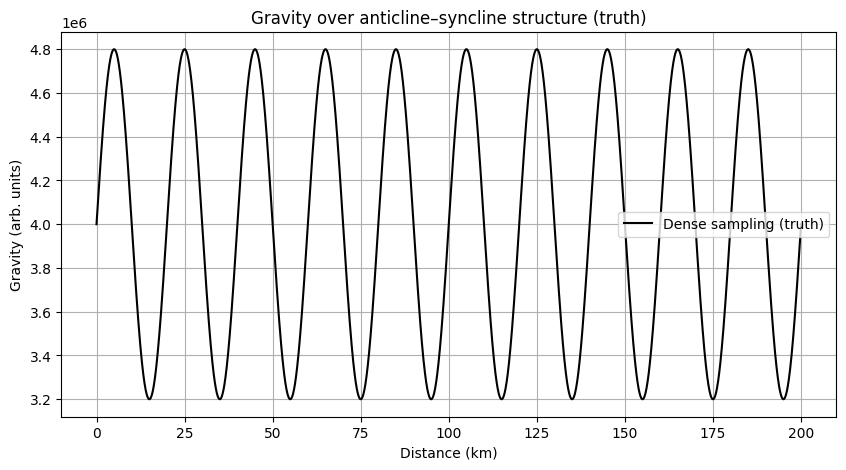

In [37]:
g_dense_fold = simple_gravity_layer(z_fold)

plt.figure()
plt.plot(x_dense/1000, g_dense_fold, 'k', label="Dense sampling (truth)")
plt.xlabel("Distance (km)")
plt.ylabel("Gravity (arb. units)")
plt.title("Gravity over anticline–syncline structure (truth)")
plt.legend()
plt.show()

> **Key observation:** The gravity signal is smooth and sinusoidal with the *same*
> wavelength as the geological interface.  The amplitude depends on the density
> contrast and the depth — deep sources produce weaker but wider anomalies than
> shallow ones.


### 1.2 Effect of station spacing on the fold gravity

**Objective:** discover the Nyquist criterion empirically.

Move the slider to coarsen the station spacing and watch what happens to the
sampled gravity curve.

> **Questions to consider:**
> - At what station spacing does the sampled signal start to look wrong?
> - What is the minimum number of stations needed per wavelength to recover the signal faithfully?
> - What happens at spacings larger than half the geological wavelength ($> 10$ km here)?


In [38]:
def sample_fold(dx_km=2.0):
    dx = dx_km * 1000
    xs = np.arange(x_dense.min(), x_dense.max(), dx)
    zs = fold_geometry(xs)
    gs = simple_gravity_layer(zs)

    plt.figure()
    plt.plot(x_dense/1000, g_dense_fold, 'k', alpha=0.25, label="Dense truth")
    plt.plot(xs/1000, gs, 'ro:', label=f"Sampled Δx = {dx_km:.1f} km")
    plt.xlabel("Distance (km)")
    plt.ylabel("Gravity (arb. units)")
    plt.title("Sampling gravity over folded geology")
    plt.legend()
    plt.show()


interact(
    sample_fold,
    dx_km=FloatSlider(min=0.5, max=15, step=0.5, value=2.0,
                      description="Station spacing (km)")
);

interactive(children=(FloatSlider(value=2.0, description='Station spacing (km)', max=15.0, min=0.5, step=0.5),…

> **Key observation (Nyquist criterion):** You need **at least two samples per
> wavelength** to resolve a signal.  For the 20 km fold, the critical station spacing
> is 10 km.  Beyond that, the sampled curve bears no resemblance to the truth —
> this is **aliasing**: short-wavelength energy is misrepresented as longer wavelengths.


### 1.3 Basin-and-Range style gravity

**Objective:** work with a more realistic multi-scale geological model that mimics
the Basin-and-Range Province of the western US.

The interface now superposes two sinusoids:
- **Shallow structure** (horst–graben spacing ~20 km, amplitude 3 km) — individual basins
- **Deep regional structure** (wavelength 120 km, amplitude 5 km) — crustal-scale flexure

Real gravity surveys see the sum of both signals, and separating them is a key challenge.


In [39]:
def basin_range_geometry(x, shallow_amp=3e3, shallow_wl=20e3,
                         deep_amp=5e3, deep_wl=120e3,
                         z0=15e3):
    """
    Superposition of shallow horst-graben and deep regional structure.
    """
    shallow = shallow_amp * np.sin(2 * np.pi * x / shallow_wl)
    deep = deep_amp * np.sin(2 * np.pi * x / deep_wl)
    return z0 + shallow + deep

z_br = basin_range_geometry(x_dense)
g_dense_br = simple_gravity_layer(z_br)

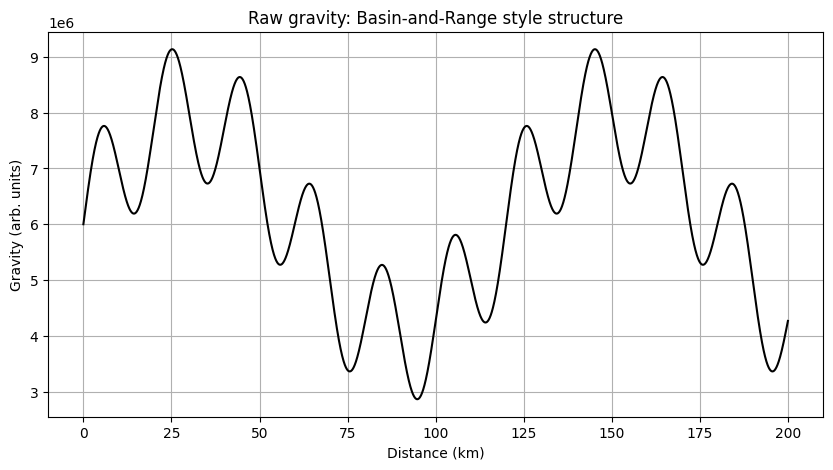

In [40]:
plt.figure()
plt.plot(x_dense/1000, g_dense_br, 'k')
plt.xlabel("Distance (km)")
plt.ylabel("Gravity (arb. units)")
plt.title("Raw gravity: Basin-and-Range style structure")
plt.show()

> **Key observation:** The long-wavelength regional signal dominates the raw gravity
> profile.  The shorter-wavelength basin signature (20 km) rides on top but is hard
> to see.  This is typical of real Bouguer gravity data — the regional background
> must be removed before basin-scale features become interpretable.


### 1.4 Removing the regional trend

**Objective:** understand polynomial detrending as a spectral high-pass filter.

Try different polynomial orders and observe how well each removes the regional
signal without distorting the shorter-wavelength basin anomalies.


In [41]:
def show_detrending(order=1):
    residual, trend = detrend(x_dense, g_dense_br, order=order)

    plt.figure()
    plt.plot(x_dense/1000, g_dense_br, 'k', alpha=0.6, label="Raw gravity")
    plt.plot(x_dense/1000, trend, 'r--', label=f"Trend (order {order})")
    plt.plot(x_dense/1000, residual, 'b', label="Residual")
    plt.xlabel("Distance (km)")
    plt.ylabel("Gravity (arb. units)")
    plt.title("Detrending gravity data")
    plt.legend()
    plt.show()


interact(
    show_detrending,
    order=Dropdown(options=[0,1,2,3], value=1, description="Trend order")
);

interactive(children=(Dropdown(description='Trend order', index=1, options=(0, 1, 2, 3), value=1), Output()), …

> **Key observation:** A first-order (linear) trend removes the gradient caused by
> the deep structure but leaves residual curvature.  A second-order polynomial does
> better.  However, very high orders begin to fit the basin anomalies themselves,
> removing the signal you want to keep.  This trade-off between regional removal
> and signal preservation is central to gravity interpretation.


### 1.5 Sampling and detrending combined

**Objective:** see how coarse sampling and detrending interact.

Try a coarse station spacing **with** detrending turned on.  Notice that even
after detrending, aliased short-wavelength energy can appear at unexpected
long wavelengths.


In [42]:
def sample_basin_range(dx_km=5.0, detrend_on=True, order=1):
    dx = dx_km * 1000
    xs = np.arange(x_dense.min(), x_dense.max(), dx)

    zs = basin_range_geometry(xs)
    gs = simple_gravity_layer(zs)

    if detrend_on:
        gs_resid, trend = detrend(xs, gs, order=order)
        plot_g = gs_resid
        label = f"Sampled + detrended (Δx={dx_km:.1f} km)"
    else:
        plot_g = gs
        label = f"Sampled raw (Δx={dx_km:.1f} km)"

    plt.figure()
    plt.plot(x_dense/1000, g_dense_br, 'k', alpha=0.2, label="Dense truth")
    plt.plot(xs/1000, plot_g, 'ro:', label=label)
    plt.xlabel("Distance (km)")
    plt.ylabel("Gravity (arb. units)")
    plt.title("Sampling + detrending in Basin-and-Range gravity")
    plt.legend()
    plt.show()


interact(
    sample_basin_range,
    dx_km=FloatSlider(min=1.0, max=20.0, step=1.0, value=5.0,
                      description="Station spacing (km)"),
    detrend_on=Checkbox(value=True, description="Apply detrending"),
    order=Dropdown(options=[0,1,2,3], value=1, description="Trend order")
);

interactive(children=(FloatSlider(value=5.0, description='Station spacing (km)', max=20.0, min=1.0, step=1.0),…

> **Key observation:** Detrending does not cure aliasing — it only removes the
> regional background.  If the station spacing violates Nyquist for the basin signal,
> the detrended residual will still be corrupted.  This motivates carrying the
> Fourier transform into the analysis to quantify exactly which wavelengths are
> resolved.


### 1.6 Introducing the spatial Fourier transform

**Objective:** convert a gravity profile from the spatial domain to the wavenumber
(spectral) domain.

The function below computes the **real FFT** of a uniformly-sampled profile.
The output wavenumber $k$ has units of cycles km$^{-1}$ and the corresponding
wavelength is $\lambda = 1/k$ km.  The amplitude at each wavenumber tells us
how much energy the signal contains at that spatial frequency.


In [43]:
def spatial_fft(x, g):
    """
    Compute 1D spatial FFT and return wavenumber (cycles/km),
    amplitude spectrum (unnormalized but comparable across cases).
    """
    dx = np.mean(np.diff(x))          # spacing in meters
    N = len(x)

    # Remove mean (DC component)
    g = g - np.mean(g)

    G = np.fft.rfft(g)
    k = np.fft.rfftfreq(N, d=dx)      # cycles / meter

    # Convert to cycles per km for readability
    k_km = k * 1000
    amp = np.abs(G)

    return k_km, amp

### 1.7 Spectrum of the fold gravity

**Objective:** confirm that the FFT recovers the known geological wavelength and
observe how aliasing appears in the spectrum when the sampling is too coarse.


In [44]:
def sample_fold_with_spectrum(dx_km=2.0):
    dx = dx_km * 1000
    xs = np.arange(x_dense.min(), x_dense.max(), dx)
    zs = fold_geometry(xs)
    gs = simple_gravity_layer(zs)

    # FFTs
    k_dense, amp_dense = spatial_fft(x_dense, g_dense_fold)
    k_s, amp_s = spatial_fft(xs, gs)

    fig, axs = plt.subplots(2, 1, figsize=(10, 8))

    # --- Spatial domain ---
    axs[0].plot(x_dense/1000, g_dense_fold, 'k', alpha=0.25, label="Dense truth")
    axs[0].plot(xs/1000, gs, 'ro:', label=f"Sampled Δx = {dx_km:.1f} km")
    axs[0].set_xlabel("Distance (km)")
    axs[0].set_ylabel("Gravity (arb.)")
    axs[0].set_title("Folded geology: spatial domain")
    axs[0].legend()

    # --- Spectral domain ---
    axs[1].plot(k_dense, amp_dense/amp_dense.max(),
                'k', alpha=0.4, label="True spectrum")
    axs[1].plot(k_s, amp_s/amp_s.max(),
                'r:', label="Sampled spectrum")
    axs[1].set_xlim(0, 0.2)
    axs[1].set_xlabel("Wavenumber (cycles/km)")
    axs[1].set_ylabel("Normalized amplitude")
    axs[1].set_title("Folded geology: spectral domain")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


interact(
    sample_fold_with_spectrum,
    dx_km=FloatSlider(min=0.5, max=15, step=0.5, value=2.0,
                      description="Station spacing (km)")
);

interactive(children=(FloatSlider(value=2.0, description='Station spacing (km)', max=15.0, min=0.5, step=0.5),…

> **Key observations:**
> - At fine station spacing the spectrum shows a **single sharp peak** at
>   the fold wavelength ($\lambda = 20$ km, $k = 0.05$ cycles km$^{-1}$).
> - As you coarsen the spacing past the Nyquist limit the peak disappears from
>   its true location and a spurious peak appears at a *different* wavelength —
>   this is the aliased energy.
> - Once aliasing occurs, **no post-processing can undo it**: the original
>   wavenumber information is permanently lost.


### 1.8 Spectrum of the Basin-and-Range gravity

**Objective:** identify multiple geological wavelengths in the spectrum and
practise using detrending to reveal the short-wavelength basin peak.

Try coarsening the spacing until the 20 km basin peak aliases, and note where
the aliased energy appears.


In [45]:
def basin_range_with_spectrum(dx_km=5.0, detrend_on=True, order=1):
    dx = dx_km * 1000
    xs = np.arange(x_dense.min(), x_dense.max(), dx)

    zs = basin_range_geometry(xs)
    gs = simple_gravity_layer(zs)

    if detrend_on:
        gs, _ = detrend(xs, gs, order=order)
        title_suffix = f" (detrended, order {order})"
    else:
        title_suffix = " (raw)"

    # FFTs
    k_dense, amp_dense = spatial_fft(x_dense, g_dense_br)
    k_s, amp_s = spatial_fft(xs, gs)

    fig, axs = plt.subplots(2, 1, figsize=(10, 8))

    # --- Spatial domain ---
    axs[0].plot(x_dense/1000, g_dense_br, 'k', alpha=0.2,
                label="Dense truth")
    axs[0].plot(xs/1000, gs, 'ro',
                label=f"Sampled Δx={dx_km:.1f} km")
    axs[0].set_xlabel("Distance (km)")
    axs[0].set_ylabel("Gravity (arb.)")
    axs[0].set_title("Basin-and-Range gravity" + title_suffix)
    axs[0].legend()

    # --- Spectral domain ---
    axs[1].plot(k_dense, amp_dense/amp_dense.max(),
                'k', alpha=0.4, label="True spectrum")
    axs[1].plot(k_s, amp_s/amp_s.max(),
                'r', label="Sampled spectrum")
    axs[1].set_xlim(0, 0.2)
    axs[1].set_xlabel("Wavenumber (cycles/km)")
    axs[1].set_ylabel("Normalized amplitude")
    axs[1].set_title("Spectral content")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


interact(
    basin_range_with_spectrum,
    dx_km=FloatSlider(min=1.0, max=20.0, step=1.0, value=5.0,
                      description="Station spacing (km)"),
    detrend_on=Checkbox(value=True, description="Apply detrending"),
    order=Dropdown(options=[0,1,2,3], value=1, description="Trend order")
);

interactive(children=(FloatSlider(value=5.0, description='Station spacing (km)', max=20.0, min=1.0, step=1.0),…

> **Key observations:**
> - With fine sampling and detrending enabled, you should see **two spectral peaks**:
>   one at ~20 km (the basin spacing) and one at ~120 km (the regional structure).
> - Without detrending the regional peak dominates and the basin peak is obscured.
> - The Nyquist wavelength is $2 \times \Delta x$.  Station spacings $>10$ km
>   alias the 20 km basin signal into the regional band — exactly where the
>   real geological signal lives.  This is why reconnaissance gravity surveys
>   with 5–10 km station spacing miss individual basin details.
